In [1]:
# Install any missing libraries
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn --quiet

# Import everything we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

2026-04-28 22:30:50.249738: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.18.0
All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('diabetes.csv')

# See the first 5 rows
print("First 5 rows:")
print(df.head())

# Shape of the dataset
print(f"\nDataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Basic statistics
print("\nBasic statistics:")
print(df.describe())

# How many diabetic vs non-diabetic
print("\nOutcome distribution:")
print(df['Outcome'].value_counts())
print(f"\n0 = Not diabetic, 1 = Diabetic")

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset shape: 768 rows, 9 columns

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age            

In [3]:
# These columns can't biologically be zero — replace with column median
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    df[col] = df[col].replace(0, df[col].median())

print("Zeros replaced with median values.")
print("\nNew basic stats for cleaned columns:")
print(df[cols_with_zeros].describe().round(2))

Zeros replaced with median values.

New basic stats for cleaned columns:
       Glucose  BloodPressure  SkinThickness  Insulin     BMI
count   768.00         768.00         768.00   768.00  768.00
mean    121.66          72.39          27.33    94.65   32.45
std      30.44          12.10           9.23   105.55    6.88
min      44.00          24.00           7.00    14.00   18.20
25%      99.75          64.00          23.00    30.50   27.50
50%     117.00          72.00          23.00    31.25   32.00
75%     140.25          80.00          32.00   127.25   36.60
max     199.00         122.00          99.00   846.00   67.10


In [4]:
# Separate features (X) from the target label (y)
X = df.drop('Outcome', axis=1)  # everything except the answer
y = df['Outcome']               # the answer: 0 or 1

# Split into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# Scale the features (make all numbers on the same scale 0-1 range)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nData scaled successfully!")
print(f"Sample of scaled training data (first row):")
print(X_train[0].round(3))

Training samples: 614
Testing samples:  154

Data scaled successfully!
Sample of scaled training data (first row):
[-0.851 -1.056 -0.827 -1.649 -0.512 -0.769  0.311 -0.792]


In [5]:
# Set random seed for reproducibility
tf.random.set_seed(42)

# Build the neural network
model = keras.Sequential([
    # Input layer — 8 features going in
    layers.Input(shape=(8,)),
    
    # Hidden layer 1 — 32 neurons, ReLU activation
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),  # randomly switch off 20% of neurons to prevent overfitting
    
    # Hidden layer 2 — 16 neurons, ReLU activation
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    
    # Output layer — 1 neuron, sigmoid gives probability between 0 and 1
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # standard loss for yes/no classification
    metrics=['accuracy']
)

# Print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,               # go through the data 100 times
    batch_size=32,            # learn from 32 patients at a time
    validation_split=0.2,     # use 20% of training data to monitor progress
    verbose=1                 # show progress
)

print("\nTraining complete!")

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6660 - loss: 0.6302 - val_accuracy: 0.7073 - val_loss: 0.5997
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6762 - loss: 0.6076 - val_accuracy: 0.6992 - val_loss: 0.5678
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7067 - loss: 0.5746 - val_accuracy: 0.6992 - val_loss: 0.5442
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6864 - loss: 0.5570 - val_accuracy: 0.7154 - val_loss: 0.5251
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6986 - loss: 0.5506 - val_accuracy: 0.7317 - val_loss: 0.5110
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7393 - loss: 0.5192 - val_accuracy: 0.7398 - val_loss: 0.4988
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7475 - loss: 0.5126 - val_accuracy: 0.7480 - val_loss: 0.4886
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7495 - loss: 0.4982 - val_accuracy: 0.7967 - 

Test Accuracy: 0.7403 (74.0%)
Test Loss:     0.5132
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Classification Report:
              precision    recall  f1-score   support

Not Diabetic       0.78      0.83      0.81       100
    Diabetic       0.65      0.57      0.61        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.74      0.74       154

ROC-AUC Score: 0.8185


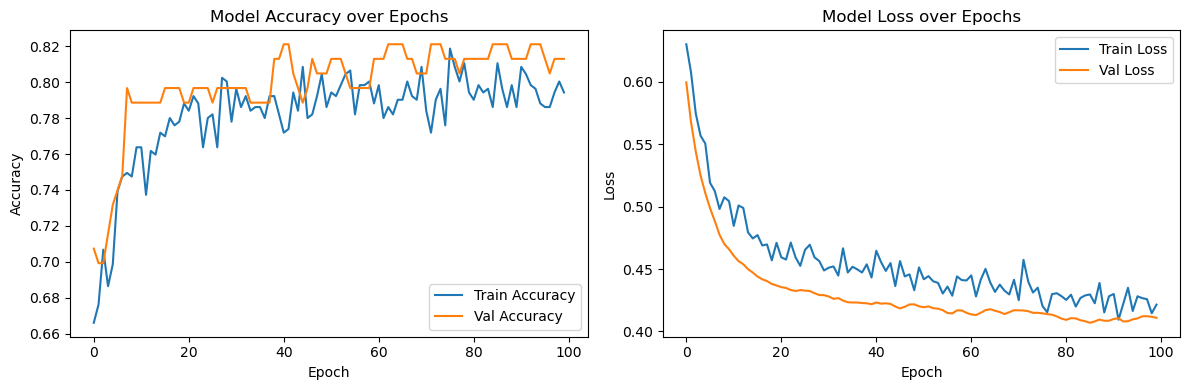

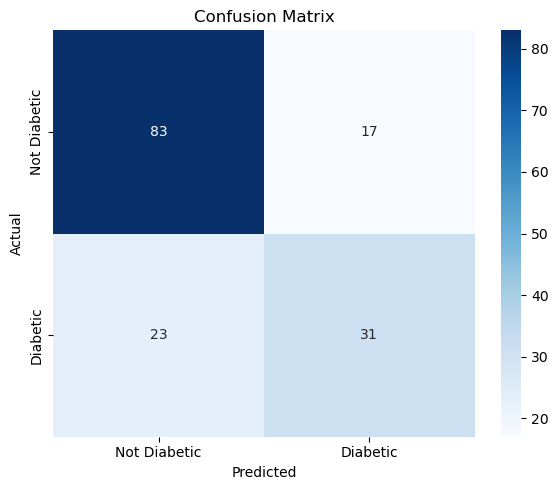


Charts saved!


In [7]:
# Evaluate on the test set (data the model has NEVER seen)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.1f}%)")
print(f"Test Loss:     {test_loss:.4f}")

# Get predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Diabetic', 'Diabetic']))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot 1: Training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Diabetic', 'Diabetic'],
            yticklabels=['Not Diabetic', 'Diabetic'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved!")

In [8]:
# Save the trained model
model.save('diabetes_model.keras')

# Save the scaler too (we need it for deployment)
import joblib
joblib.dump(scaler, 'scaler.pkl')

print("Model saved as: diabetes_model.keras")
print("Scaler saved as: scaler.pkl")

# Verify files are there
import os
files = ['diabetes_model.keras', 'scaler.pkl', 
         'training_history.png', 'confusion_matrix.png']
for f in files:
    size = os.path.getsize(f)
    print(f"✓ {f} ({size} bytes)")

Model saved as: diabetes_model.keras
Scaler saved as: scaler.pkl
✓ diabetes_model.keras (39738 bytes)
✓ scaler.pkl (1159 bytes)
✓ training_history.png (130664 bytes)
✓ confusion_matrix.png (31280 bytes)


In [9]:
import boto3
import sagemaker
from sagemaker import get_execution_role
import tarfile
import os

# Get your SageMaker role and session
role = get_execution_role()
session = sagemaker.Session()
bucket = session.default_bucket()  # uses your default SageMaker S3 bucket
prefix = 'diabetes-model'

print(f"Role: {role}")
print(f"Bucket: {bucket}")

# Package the model into a tar.gz file (SageMaker requires this format)
with tarfile.open('model.tar.gz', 'w:gz') as tar:
    tar.add('diabetes_model.keras')
    tar.add('scaler.pkl')

print("Model packaged into model.tar.gz")

# Upload to S3
model_uri = session.upload_data(
    path='model.tar.gz',
    bucket=bucket,
    key_prefix=prefix
)

print(f"\nModel uploaded to S3:")
print(f"{model_uri}")

sagemaker.config INFO - Fetched defaults config from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
Role: arn:aws:iam::742932328984:role/service-role/AmazonSageMakerAdminIAMExecutionRole
Bucket: amazon-sagemaker-742

In [10]:
# Create the inference script that SageMaker will use
inference_code = '''
import os
import json
import numpy as np
import joblib
import tensorflow as tf

def model_fn(model_dir):
    """Load model and scaler from the model directory."""
    model = tf.keras.models.load_model(os.path.join(model_dir, 'diabetes_model.keras'))
    scaler = joblib.load(os.path.join(model_dir, 'scaler.pkl'))
    return model, scaler

def input_fn(request_body, request_content_type):
    """Parse incoming request data."""
    if request_content_type == 'application/json':
        data = json.loads(request_body)
        return np.array(data['instances'])
    raise ValueError(f"Unsupported content type: {request_content_type}")

def predict_fn(input_data, model_and_scaler):
    """Scale input and run prediction."""
    model, scaler = model_and_scaler
    scaled = scaler.transform(input_data)
    predictions = model.predict(scaled)
    return predictions

def output_fn(predictions, response_content_type):
    """Format the prediction output."""
    results = []
    for prob in predictions:
        result = {
            "probability": float(prob[0]),
            "prediction": "Diabetic" if prob[0] > 0.5 else "Not Diabetic",
            "confidence": f"{max(prob[0], 1-prob[0])*100:.1f}%"
        }
        results.append(result)
    return json.dumps(results)
'''

# Save it as inference.py
os.makedirs('code', exist_ok=True)
with open('code/inference.py', 'w') as f:
    f.write(inference_code)

print("✓ inference.py created successfully!")
print("\nThis script tells SageMaker how to:")
print("  - Load your model (model_fn)")
print("  - Accept patient data (input_fn)")
print("  - Make predictions (predict_fn)")
print("  - Return results (output_fn)")

✓ inference.py created successfully!

This script tells SageMaker how to:
  - Load your model (model_fn)
  - Accept patient data (input_fn)
  - Make predictions (predict_fn)
  - Return results (output_fn)


In [11]:
from sagemaker.tensorflow import TensorFlowModel

# Create the SageMaker model object
sagemaker_model = TensorFlowModel(
    model_data=model_uri,
    role=role,
    framework_version='2.13',
    py_version='py310',
    source_dir='code',
    entry_point='inference.py'
)

print("Deploying model to SageMaker endpoint...")
print("⏳ This takes 5-10 minutes — do not close the notebook!\n")

# Deploy to a real-time endpoint
predictor = sagemaker_model.deploy(
    initial_instance_count=1,
    instance_type='ml.t2.medium',  # cheapest instance — good for testing
    endpoint_name='diabetes-prediction-endpoint'
)

print("\n✅ Deployment complete!")
print(f"Endpoint name: diabetes-prediction-endpoint")
print("Your model is now live and accepting predictions!")

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:4                                                                                    │
│                                                                                                  │
│    1 from sagemaker.tensorflow import TensorFlowModel                                            │
│    2                                                                                             │
│    3 # Create the SageMaker model object                                                         │
│ ❱  4 sagemaker_model = TensorFlowModel(                                                          │
│    5 │   model_data=model_uri,                                                                   │
│    6 │   role=role,                                                                              │
│    7 │   framework_version='2.13',                                                               │
│                                                                                                  │
│ /opt/conda/lib/python3.11/site-packages/sagemaker/tensorflow/model.py:207 in __init__            │
│                                                                                                  │
│   204 │   │   self.inference_framework_version = training_inference_version_mismatch_dict.get(   │
│   205 │   │   │   framework_version, framework_version                                           │
│   206 │   │   )                                                                                  │
│ ❱ 207 │   │   super(TensorFlowModel, self).__init__(                                             │
│   208 │   │   │   model_data=model_data,                                                         │
│   209 │   │   │   role=role,                                                                     │
│   210 │   │   │   image_uri=image_uri,                                                           │
│                                                                                                  │
│ /opt/conda/lib/python3.11/site-packages/sagemaker/model.py:2153 in __init__                      │
│                                                                                                  │
│   2150 │   │   │   You can find additional parameters for initializing this class at             │
│   2151 │   │   │   :class:`~sagemaker.model.Model`.                                              │
│   2152 │   │   """                                                                               │
│ ❱ 2153 │   │   super(FrameworkModel, self).__init__(                                             │
│   2154 │   │   │   image_uri,                                                                    │
│   2155 │   │   │   model_data,                                                                   │
│   2156 │   │   │   role,                                                                         │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
TypeError: Model.__init__() got an unexpected keyword argument 'py_version'

In [12]:
from sagemaker.tensorflow import TensorFlowModel

# Create the SageMaker model object — using tf 2.12 which is fully supported
sagemaker_model = TensorFlowModel(
    model_data=model_uri,
    role=role,
    framework_version='2.12',
    py_version='py310'
)

print("Deploying model to SageMaker endpoint...")
print("⏳ This takes 5-10 minutes — do not close the notebook!\n")

# Deploy to a real-time endpoint
predictor = sagemaker_model.deploy(
    initial_instance_count=1,
    instance_type='ml.t2.medium',
    endpoint_name='diabetes-prediction-endpoint'
)

print("\n✅ Deployment complete!")
print(f"Endpoint name: diabetes-prediction-endpoint")
print("Your model is now live and accepting predictions!")

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:4                                                                                    │
│                                                                                                  │
│    1 from sagemaker.tensorflow import TensorFlowModel                                            │
│    2                                                                                             │
│    3 # Create the SageMaker model object — using tf 2.12 which is fully supported                │
│ ❱  4 sagemaker_model = TensorFlowModel(                                                          │
│    5 │   model_data=model_uri,                                                                   │
│    6 │   role=role,                                                                              │
│    7 │   framework_version='2.12',                                                               │
│                                                                                                  │
│ /opt/conda/lib/python3.11/site-packages/sagemaker/tensorflow/model.py:207 in __init__            │
│                                                                                                  │
│   204 │   │   self.inference_framework_version = training_inference_version_mismatch_dict.get(   │
│   205 │   │   │   framework_version, framework_version                                           │
│   206 │   │   )                                                                                  │
│ ❱ 207 │   │   super(TensorFlowModel, self).__init__(                                             │
│   208 │   │   │   model_data=model_data,                                                         │
│   209 │   │   │   role=role,                                                                     │
│   210 │   │   │   image_uri=image_uri,                                                           │
│                                                                                                  │
│ /opt/conda/lib/python3.11/site-packages/sagemaker/model.py:2153 in __init__                      │
│                                                                                                  │
│   2150 │   │   │   You can find additional parameters for initializing this class at             │
│   2151 │   │   │   :class:`~sagemaker.model.Model`.                                              │
│   2152 │   │   """                                                                               │
│ ❱ 2153 │   │   super(FrameworkModel, self).__init__(                                             │
│   2154 │   │   │   image_uri,                                                                    │
│   2155 │   │   │   model_data,                                                                   │
│   2156 │   │   │   role,                                                                         │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
TypeError: Model.__init__() got an unexpected keyword argument 'py_version'

In [13]:
import sagemaker
print("SageMaker version:", sagemaker.__version__)

# Check what arguments TensorFlowModel accepts
from sagemaker.tensorflow import TensorFlowModel
import inspect
print("\nTensorFlowModel parameters:")
print(inspect.signature(TensorFlowModel.__init__))

SageMaker version: 2.254.1

TensorFlowModel parameters:
(self, model_data: Union[str, sagemaker.workflow.entities.PipelineVariable], role: str = None, entry_point: Optional[str] = None, image_uri: Union[str, sagemaker.workflow.entities.PipelineVariable, NoneType] = None, framework_version: Optional[str] = None, container_log_level: Optional[int] = None, predictor_cls: Optional[Callable] = <class 'sagemaker.tensorflow.model.TensorFlowPredictor'>, **kwargs)


In [ ]:
from sagemaker.tensorflow import TensorFlowModel

# Correct syntax for SageMaker 2.254.1
sagemaker_model = TensorFlowModel(
    model_data=model_uri,
    role=role,
    framework_version='2.12',
    entry_point='inference.py',
    source_dir='code'
)

print("Model object created successfully!")
print("Deploying now — this takes 5–10 minutes, don't close the notebook...\n")

predictor = sagemaker_model.deploy(
    initial_instance_count=1,
    instance_type='ml.t2.medium',
    endpoint_name='diabetes-prediction-endpoint'
)

print("\n✅ Deployment complete!")
print("Endpoint name: diabetes-prediction-endpoint")
print("Your model is now live!")

Model object created successfully!
Deploying now — this takes 5–10 minutes, don't close the notebook...

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
-----------------